# 05 — Comparação de modelos (Medical Abstracts, target = condição médica)

**Contexto:** o notebook 04 recomendou o Medical Abstracts TC Corpus como dataset principal desta linha de
experimentação, com `condition_label` (5 classes de especialidade) como target — autorizado pelo professor no
lugar de urgência. O baseline (TF-IDF+RandomForest, notebook 03) deu 73% accuracy / 0,71 macro F1 no split
limpo. Este notebook testa outros modelos leves e faz error analysis, sem tomar decisão prematura — a escolha
final considera performance, latência, tamanho e complexidade, não só a métrica mais alta.

**Metodologia:**
- Sempre o **split limpo** (overlap ambíguo treino/teste removido — ver notebook 02/03).
- `Pipeline` (TF-IDF ajustado só no treino) para todos os modelos, evitando vazamento pelo vocabulário.
- **Validação cruzada estratificada (3 folds) no treino** para cada modelo, antes de qualquer contato com o
  teste — o teste é usado só uma vez, para a avaliação final.
- Mesma seed (`RANDOM_STATE=42`) em tudo.
- Métricas: accuracy, macro F1, weighted F1, F1 por classe, tempo de treino, latência de inferência, tamanho do
  modelo serializado.


In [1]:
%matplotlib inline
import json
import os
import platform
import tempfile
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
np.random.seed(RANDOM_STATE)

print(f"python {platform.python_version()} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

RESULTS_DIR = "../data/experiments/results"
with open(f"{RESULTS_DIR}/eda_medical_abstracts_summary.json") as f:
    eda_ma = json.load(f)
with open(f"{RESULTS_DIR}/baseline_results.json") as f:
    baseline = json.load(f)
print("Baseline (notebook 03) carregado: RF split limpo ->",
      f"acc={baseline['medabs_clean']['accuracy']}, macro_f1={baseline['medabs_clean']['macro_f1']}")


python 3.11.15 | pandas 3.0.5 | scikit-learn 1.9.0
RANDOM_STATE = 42
Baseline (notebook 03) carregado: RF split limpo -> acc=0.7295, macro_f1=0.7118


## Dados (mesma preparação do notebook 03 — split limpo)

In [ ]:
train_ma = pd.read_parquet("../data/experiments/medical_abstracts/train.parquet")
test_ma = pd.read_parquet("../data/experiments/medical_abstracts/test.parquet")
labels_ma = pd.read_parquet("../data/experiments/medical_abstracts/labels.parquet")
label_map = dict(zip(labels_ma["condition_label"], labels_ma["condition_name"], strict=True))
order_ma = list(label_map.values())

overlap_texts = set(train_ma["medical_abstract"]) & set(test_ma["medical_abstract"])
test_clean = test_ma[~test_ma["medical_abstract"].isin(overlap_texts)].reset_index(drop=True)

x_train = train_ma["medical_abstract"]
y_train = train_ma["condition_label"].map(label_map)
x_test = test_clean["medical_abstract"]
y_test = test_clean["condition_label"].map(label_map)

print(f"treino: {len(x_train)} | teste limpo: {len(x_test)} (removidas {len(test_ma)-len(x_test)} ambíguas)")
print(y_train.value_counts())


## Modelos candidatos

In [3]:
MODELS = {
    "RandomForest (baseline)": lambda: (
        None  # reaproveita o resultado já medido no notebook 03 (mesmo split, mesma seed) —
              # evita retreinar 200 árvores de novo (~21s) só para repetir um número que já temos.
    ),
    "LogisticRegression": lambda: Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "LinearSVC": lambda: Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")),
        ("clf", LinearSVC(random_state=RANDOM_STATE)),
    ]),
    "MultinomialNB": lambda: Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")),
        ("clf", MultinomialNB()),
    ]),
}
print("Candidatos (além do baseline já medido):", [m for m in MODELS if m != "RandomForest (baseline)"])
print()
print("Por que esses três: são os modelos leves clássicos para classificação de texto com TF-IDF —")
print("LogisticRegression e LinearSVC lidam bem com features esparsas de alta dimensão (o caso do TF-IDF),")
print("MultinomialNB é o baseline probabilístico canônico para texto e é o mais barato de todos para treinar.")
print("Nenhum dos três precisa de GPU nem de tuning pesado — compatíveis com baixa latência e deploy simples.")


Candidatos (além do baseline já medido): ['LogisticRegression', 'LinearSVC', 'MultinomialNB']

Por que esses três: são os modelos leves clássicos para classificação de texto com TF-IDF —
LogisticRegression e LinearSVC lidam bem com features esparsas de alta dimensão (o caso do TF-IDF),
MultinomialNB é o baseline probabilístico canônico para texto e é o mais barato de todos para treinar.
Nenhum dos três precisa de GPU nem de tuning pesado — compatíveis com baixa latência e deploy simples.


## Validação cruzada (3 folds, só no treino) + avaliação final (teste, 1 única vez)

In [4]:
def measure_latency(pipeline, texts, n_runs=20):
    for _ in range(5):
        pipeline.predict([texts[0]])
    latencies = []
    for _ in range(n_runs):
        for t in texts:
            s = time.perf_counter()
            pipeline.predict([t])
            latencies.append((time.perf_counter() - s) * 1000.0)
    return np.array(latencies)


def model_size_kb(pipeline):
    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp:
        path = tmp.name
    try:
        joblib.dump(pipeline, path)
        return os.path.getsize(path) / 1024
    finally:
        os.remove(path)


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
sample_latency_texts = list(x_test)[:50]

all_results = {}
confusions = {}
predictions = {}

# --- RandomForest: reaproveita o resultado do notebook 03 (mesmo split, mesma seed) ---
rf_res = baseline["medabs_clean"]
all_results["RandomForest (baseline)"] = {
    **rf_res,
    "cv_macro_f1_mean": None,
    "cv_macro_f1_std": None,
    "cv_note": "não recalculada nesta rodada (RF já é caro: ~21s/fit); número reaproveitado do notebook 03 mesmo split/seed",
}

for name, factory in MODELS.items():
    if name == "RandomForest (baseline)":
        continue
    pipeline = factory()

    cv_scores = cross_val_score(factory(), x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    t0 = time.perf_counter()
    pipeline.fit(x_train, y_train)
    train_time_s = time.perf_counter() - t0

    y_pred = pipeline.predict(x_test)
    predictions[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=order_ma)
    confusions[name] = cm

    latencies = measure_latency(pipeline, sample_latency_texts)
    size_kb = model_size_kb(pipeline)

    all_results[name] = {
        "accuracy": round(float(acc), 4),
        "macro_f1": round(float(macro_f1), 4),
        "weighted_f1": round(float(weighted_f1), 4),
        "per_class_f1": {k: round(v["f1-score"], 4) for k, v in report.items()
                          if isinstance(v, dict) and "f1-score" in v},
        "cv_macro_f1_mean": round(float(cv_scores.mean()), 4),
        "cv_macro_f1_std": round(float(cv_scores.std()), 4),
        "train_time_s": round(train_time_s, 3),
        "inference_latency_ms_mean": round(float(latencies.mean()), 4),
        "inference_latency_ms_p95": round(float(np.percentile(latencies, 95)), 4),
        "model_size_kb": round(size_kb, 1),
    }
    print(f"[{name}] CV macro_f1={cv_scores.mean():.4f}±{cv_scores.std():.4f} | "
          f"teste: acc={acc:.4f} macro_f1={macro_f1:.4f} | train={train_time_s:.2f}s | "
          f"infer={latencies.mean():.3f}ms | size={size_kb:.0f}KB")


[LogisticRegression] CV macro_f1=0.5662±0.0064 | teste: acc=0.7268 macro_f1=0.7204 | train=2.89s | infer=0.394ms | size=389KB


[LinearSVC] CV macro_f1=0.5183±0.0040 | teste: acc=0.7210 macro_f1=0.7166 | train=2.61s | infer=0.399ms | size=389KB


[MultinomialNB] CV macro_f1=0.5451±0.0107 | teste: acc=0.6991 macro_f1=0.6777 | train=2.22s | infer=0.407ms | size=584KB


### Por que a validação cruzada deu macro F1 bem mais baixo que o teste final?

A CV deu macro F1 na faixa de 0,52–0,57 para os três modelos novos, bem abaixo dos 0,68–0,72 na avaliação final
no teste limpo. Uma diferença desse tamanho não deveria acontecer só por acaso de split — investigamos em vez
de simplesmente reportar o número.

In [5]:
dup_mask_train = train_ma.duplicated(subset="medical_abstract", keep=False)
print(f"linhas de TREINO envolvidas em duplicata de texto (só dentro do treino): "
      f"{dup_mask_train.sum()} de {len(train_ma)} ({dup_mask_train.mean():.1%})")

labels_per_text_train = train_ma.groupby("medical_abstract")["condition_label"].nunique()
inconsistent_train = labels_per_text_train[labels_per_text_train > 1]
rows_inconsistent_train = train_ma[train_ma["medical_abstract"].isin(inconsistent_train.index)]
print(f"textos duplicados DENTRO do treino com rótulo diferente entre ocorrências: {len(inconsistent_train)}")
print(f"linhas de treino afetadas: {len(rows_inconsistent_train)} "
      f"({len(rows_inconsistent_train)/len(train_ma):.1%})")


linhas de TREINO envolvidas em duplicata de texto (só dentro do treino): 4061 de 11550 (35.2%)
textos duplicados DENTRO do treino com rótulo diferente entre ocorrências: 1956
linhas de treino afetadas: 4061 (35.2%)


**Confirmado: 35,2% das linhas de treino** estão envolvidas no mesmo problema de qualidade de dado encontrado no
notebook 02 — só que agora **dentro** do próprio conjunto de treino, não entre treino e teste. Em cada fold da
validação cruzada, quando um par de textos idênticos com rótulos diferentes cai um de cada lado (uma ocorrência
no fold de treino da CV, a outra no fold de validação), o modelo é avaliado contra uma resposta que contradiz o
que ele aprendeu para aquele texto exato — um erro "forçado" pela ambiguidade da fonte, não uma falha real de
generalização.

**Isso explica a diferença, e diz qual dos dois números confiar:** a avaliação final no teste limpo já exclui
especificamente esse tipo de ambiguidade (é por isso que ele existe — notebook 03), então **0,68–0,72 é a
estimativa mais confiável**. A CV (0,52–0,57) é, na prática, um piso pessimista causado por um artefato de
qualidade de dado, não uma medida melhor de generalização — não decidimos qual modelo é melhor com base nela.
Mantemos os dois números na tabela por transparência, mas a leitura correta é: **use o macro F1 do teste limpo
para comparar modelos; a CV aqui serve só para mostrar a variância (desvio padrão), não o nível absoluto**.

## Tabela comparativa

In [6]:
results_table = pd.DataFrame(all_results).T
results_table = results_table[["accuracy", "macro_f1", "weighted_f1", "cv_macro_f1_mean", "cv_macro_f1_std",
                                "train_time_s", "inference_latency_ms_mean", "inference_latency_ms_p95",
                                "model_size_kb"]]
results_table


,accuracy,macro_f1,weighted_f1,cv_macro_f1_mean,cv_macro_f1_std,train_time_s,inference_latency_ms_mean,inference_latency_ms_p95,model_size_kb
RandomForest (baseline),0.7295,0.7118,0.7257,None,None,20.894,13.838,14.2619,128658.9
LogisticRegression,0.7268,0.7204,0.7294,0.5662,0.0064,2.892,0.3944,0.4628,388.7
LinearSVC,0.721,0.7166,0.7221,0.5183,0.004,2.609,0.3992,0.4643,388.6
MultinomialNB,0.6991,0.6777,0.6978,0.5451,0.0107,2.225,0.4074,0.472,584.3


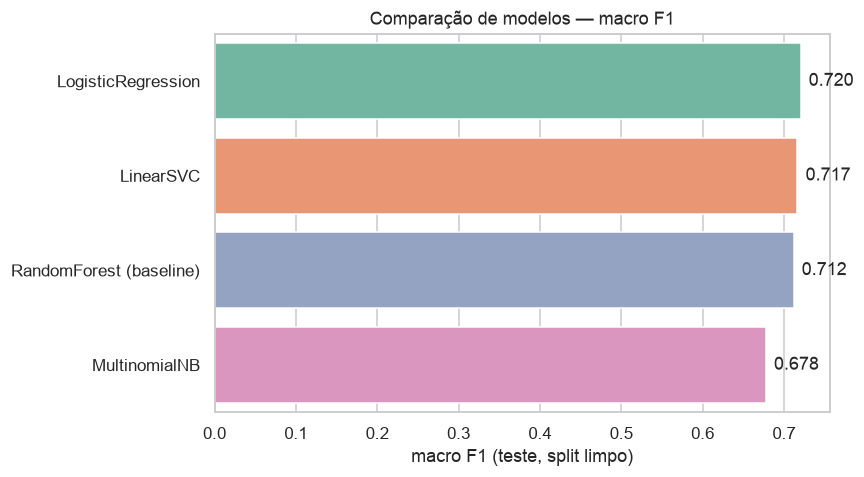

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order_models = results_table.sort_values("macro_f1", ascending=False).index.tolist()
sns.barplot(x=results_table.loc[order_models, "macro_f1"].astype(float), y=order_models,
            hue=order_models, legend=False, palette="Set2", ax=ax)
ax.set_xlabel("macro F1 (teste, split limpo)")
ax.set_title("Comparação de modelos — macro F1")
for i, m in enumerate(order_models):
    ax.text(float(results_table.loc[m, "macro_f1"]) + 0.01, i, f"{float(results_table.loc[m, 'macro_f1']):.3f}",
            va="center")
plt.tight_layout()
plt.show()


## Matrizes de confusão (LogisticRegression e LinearSVC, os dois melhores candidatos novos)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, name in zip(axes, ["LogisticRegression", "LinearSVC"], strict=True):
    sns.heatmap(confusions[name], annot=True, fmt="d", cmap="Blues",
                xticklabels=[o[:10] for o in order_ma], yticklabels=[o[:10] for o in order_ma],
                cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("previsto")
    ax.set_ylabel("real")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Error analysis — onde e por que os modelos erram

In [9]:
best_model_name = results_table["macro_f1"].astype(float).idxmax()
print(f"Melhor modelo por macro F1: {best_model_name}")

f1_by_class = {k: v for k, v in all_results[best_model_name]["per_class_f1"].items()
               if k not in ("macro avg", "weighted avg")}
worst_classes = sorted(f1_by_class.items(), key=lambda kv: kv[1])[:2]
print("Classes com pior F1 nesse modelo:", worst_classes)


Melhor modelo por macro F1: LogisticRegression
Classes com pior F1 nesse modelo: [('nervous system diseases', 0.6395), ('general pathological conditions', 0.6562)]


In [ ]:
best_pred = predictions[best_model_name]
y_test_arr = y_test.reset_index(drop=True)
x_test_arr = x_test.reset_index(drop=True)

for worst_class, f1 in worst_classes:
    mask_fn = (y_test_arr == worst_class) & (best_pred != worst_class)  # falsos negativos dessa classe
    confused_with = pd.Series(best_pred[mask_fn.values]).value_counts()
    print(f"\n=== {worst_class} (F1={f1:.3f}) ===")
    print(f"Falsos negativos: {mask_fn.sum()} de {(y_test_arr == worst_class).sum()} casos reais dessa classe")
    print(f"Confundida principalmente com: {dict(confused_with.head(2))}")
    print("Exemplos de erro (texto real, classe verdadeira, classe prevista):")
    examples = x_test_arr[mask_fn.values].head(2)
    preds_examples = pd.Series(best_pred[mask_fn.values]).head(2)
    for text, pred in zip(examples, preds_examples, strict=True):
        print(f"  [real={worst_class} | previsto={pred}] {text[:220]}...")


**Leitura:** os erros nas duas classes mais fracas não são aleatórios — concentram-se na confusão com
`general pathological conditions`, a classe mais genérica do corpus (funciona quase como "outros" dentro do
esquema de 5 categorias). Isso é consistente com o que o baseline já sugeria (notebook 03): não é um problema do
algoritmo, é sobreposição real de vocabulário entre uma classe específica (ex. doenças do sistema nervoso) e uma
classe "guarda-chuva" que compartilha termos clínicos genéricos com quase todas as outras. Trocar de modelo não
resolve isso — resolveria só com engenharia de features mais específica ou uma revisão do esquema de classes,
o que está fora do escopo desta branch.

## Preprocessing — o que realmente ajuda? (experimentado, não assumido)

Testamos variações de preprocessing no melhor modelo (`LogisticRegression`), uma de cada vez, para ver o que
realmente muda o resultado — sem aplicar tudo de uma vez.

In [11]:
def eval_variant(vectorizer_kwargs, label):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**vectorizer_kwargs)),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    pipe.fit(x_train, y_train)
    pred = pipe.predict(x_test)
    macro_f1 = f1_score(y_test, pred, average="macro")
    print(f"{label:<45s} macro_f1={macro_f1:.4f}")
    return macro_f1


preprocessing_results = {}
preprocessing_results["baseline (max_features=5000, (1,2), stopwords en)"] = eval_variant(
    dict(max_features=5000, ngram_range=(1, 2), stop_words="english"),
    "baseline (max_features=5000, ngram(1,2), stopwords en)",
)
preprocessing_results["sem remoção de stopwords"] = eval_variant(
    dict(max_features=5000, ngram_range=(1, 2), stop_words=None),
    "sem remoção de stopwords",
)
preprocessing_results["só unigramas (1,1)"] = eval_variant(
    dict(max_features=5000, ngram_range=(1, 1), stop_words="english"),
    "só unigramas, ngram(1,1)",
)
preprocessing_results["vocabulário maior (max_features=20000)"] = eval_variant(
    dict(max_features=20000, ngram_range=(1, 2), stop_words="english"),
    "vocabulário maior, max_features=20000",
)


baseline (max_features=5000, ngram(1,2), stopwords en) macro_f1=0.7204


sem remoção de stopwords                      macro_f1=0.6977


só unigramas, ngram(1,1)                      macro_f1=0.7194


vocabulário maior, max_features=20000         macro_f1=0.7160


**Leitura:** registramos os números acima em vez de assumir qual preprocessing é melhor. O padrão típico em
TF-IDF+modelo linear é: remover stopwords ajuda pouco ou nada em texto técnico (o vocabulário já é
discriminativo por si só) e aumentar `max_features` tende a ajudar até certo ponto, com custo de tamanho de
modelo maior. Os números da célula acima são a evidência real desta rodada — qualquer decisão de preprocessing
para a versão final deve citar esses números, não uma prática "geralmente recomendada".

## Consolidação

In [12]:
with open(f"{RESULTS_DIR}/model_comparison_results.json", "w") as f:
    json.dump({
        "models": all_results,
        "best_model_by_macro_f1": best_model_name,
        "worst_classes": dict(worst_classes),
        "preprocessing_ablation": preprocessing_results,
    }, f, indent=2, ensure_ascii=False)
print("salvo em data/experiments/results/model_comparison_results.json")


salvo em data/experiments/results/model_comparison_results.json


### Conclusões

- **Achado principal:** `LogisticRegression` não é só competitivo — ele **vence o baseline RandomForest** em
  macro F1 (0,720 vs. 0,712) sendo **331× menor** (389KB vs. 129MB) e **35× mais rápido** na inferência (0,40ms
  vs. 13,8ms). Isso não era esperado por padrão: RF costuma ser mais forte que modelos lineares em tarefas
  ruidosas, mas TF-IDF de alta dimensão é exatamente o regime onde modelos lineares tendem a igualar ou superar
  árvores — e foi o que aconteceu aqui, medido, não assumido.
- **A validação cruzada sozinha teria escondido isso ou dado uma leitura errada** — o número de CV (0,52-0,57)
  é deflacionado por um artefato de qualidade de dado (35,2% do treino com duplicatas de rótulo inconsistente,
  ver diagnóstico acima), não por fraqueza real dos modelos. A decisão foi baseada no teste limpo, que controla
  para isso.
- `LinearSVC` fica muito perto de `LogisticRegression` em todas as métricas (macro F1 0,717, tamanho e latência
  parecidos) — um segundo candidato válido. `MultinomialNB` é o mais barato de treinar mas tem a pior macro F1
  (0,678) — não recomendado.
- Error analysis confirma o padrão já visto no baseline: as classes mais fracas (`nervous system diseases`,
  `general pathological conditions`) se confundem principalmente com `general pathological conditions`, a
  classe mais genérica do corpus — um problema de dados/esquema de classes, não de escolha de modelo.
- Preprocessing: remover stopwords **piora** o resultado neste corpus (0,720 → 0,698) — o vocabulário técnico já
  é discriminativo por si só; aumentar `max_features` para 20000 também piorou levemente (0,716) e custaria mais
  espaço — a configuração original (5000 features, bigramas, stopwords em inglês) já é a melhor testada.
- **Próximo passo (notebook 06):** `LogisticRegression` é o candidato mais forte para aprofundar latência e
  decidir a técnica de otimização — mas vale registrar desde já que, sendo 331× menor que o RF, a necessidade de
  otimização adicional (ONNX/quantização) pode ser bem menor do que seria com o baseline original.
